<a href="https://colab.research.google.com/github/dexemy3210/Portfolio-Website/blob/main/Copy_of_Phase3_Model_Training_Evaluation_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd

FILE_PATH = '/content/Data Preprocessing and Exploration.xlsx'  # Corrected path

df = pd.read_excel(FILE_PATH, sheet_name='Cleaned Data')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (7413, 51)


,Category,Alpha Carotene,Mineral Content,Beta Carotene,Beta Cryptoxanthin,Carbohydrate,Cholesterol,Choline,Fiber,Kilocalories,...,Vitamins.Vitamin B6,Vitamins.Vitamin C,Vitamins.Vitamin E,Vitamins.Vitamin K,Nutrient_Sum,PCA_Comp_1,PCA_Comp_2,PCA_Comp_3,PCA_Comp_4,PCA_Comp_5
0,111,0.0,0.021142,0.003684,0.0,0.000671,0.069355,0.013689,0.0,0.811086,...,0.000250,0.0,0.015529,0.004083,0.835329,-0.450489,0.359530,0.971587,0.003362,0.026287
1,111,0.0,0.021142,0.003684,0.0,0.000671,0.070645,0.013689,0.0,0.811086,...,0.000250,0.0,0.015529,0.004083,0.835329,-0.452045,0.362495,0.977327,0.003430,0.024904
2,112,0.0,0.000000,0.004500,0.0,0.000000,0.082581,0.015850,0.0,0.990950,...,0.000083,0.0,0.018742,0.005016,1.002560,-0.656398,0.493734,1.184926,0.016660,0.033628
3,184,0.0,0.051202,0.001725,0.0,0.026178,0.024194,0.010807,0.0,0.399321,...,0.013833,0.0,0.001673,0.001400,0.906678,-0.035539,0.442033,0.120286,-0.120151,0.059449
4,184,0.0,0.031864,0.001772,0.0,0.031212,0.030323,0.010807,0.0,0.419683,...,0.005417,0.0,0.001740,0.001458,0.972108,-0.054140,0.489313,0.108063,-0.125619,0.068705


In [27]:
df['FoodGroup'] = df['Category'] // 100

print('Food Group Distribution:')
print(df['FoodGroup'].value_counts().sort_index())
print(f'\nNumber of Classes: {df["FoodGroup"].nunique()}')

Food Group Distribution:
FoodGroup
0     1221
1     1189
2      556
3      460
4      379
5      482
6      326
7      700
8      834
9      496
10     461
11     309
Name: count, dtype: int64

Number of Classes: 12


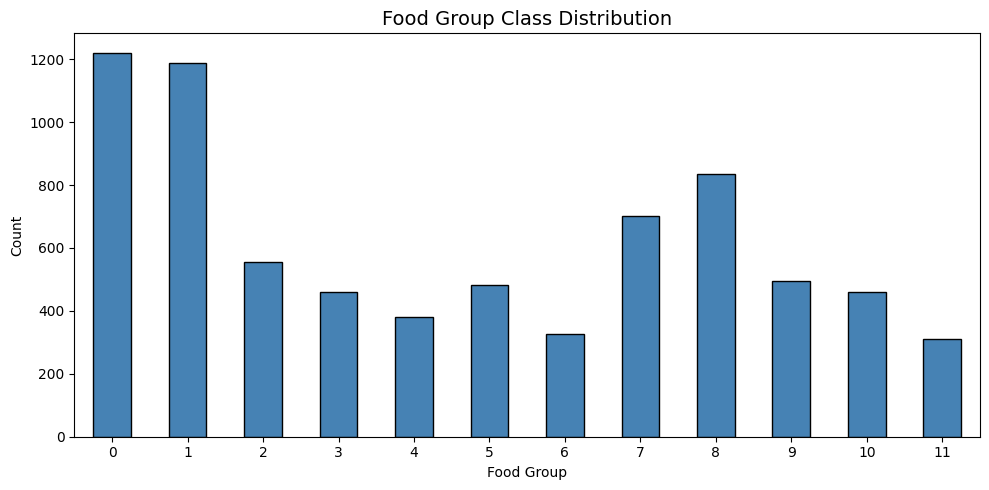

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
df['FoodGroup'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Food Group Class Distribution', fontsize=14)
plt.xlabel('Food Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
from sklearn.preprocessing import LabelEncoder

drop_cols = ['Category', 'FoodGroup']
X = df.drop(columns=drop_cols)
y = df['FoodGroup']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y_encoded.shape}')
print(f'Classes        : {le.classes_}')

Features shape : (7413, 50)
Target shape   : (7413,)
Classes        : [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')

Training set   : 5930 samples
Test set       : 1483 samples


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd # Re-import pandas as it might be needed for results_df

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=100, random_state=42,
                                         use_label_encoder=False, eval_metric='mlogloss',
                                         n_jobs=-1, verbosity=0)
}

results = []

for name, model in models.items():
    print(f'Training: {name} ...', end=' ')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1-Score': f1})
    print(f'Accuracy = {acc:.4f}')

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print('\n--- Model Comparison ---')
print(results_df.to_string(index=False))

Training: Logistic Regression ... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy = 0.2589
Training: Decision Tree ... Accuracy = 0.6022
Training: Random Forest ... Accuracy = 0.7640
Training: XGBoost ... Accuracy = 0.7579

--- Model Comparison ---
              Model  Accuracy  Precision   Recall  F1-Score
      Random Forest  0.763992   0.767022 0.763992  0.759797
            XGBoost  0.757923   0.760442 0.757923  0.754866
      Decision Tree  0.602158   0.600604 0.602158  0.600121
Logistic Regression  0.258935   0.216132 0.258935  0.188595


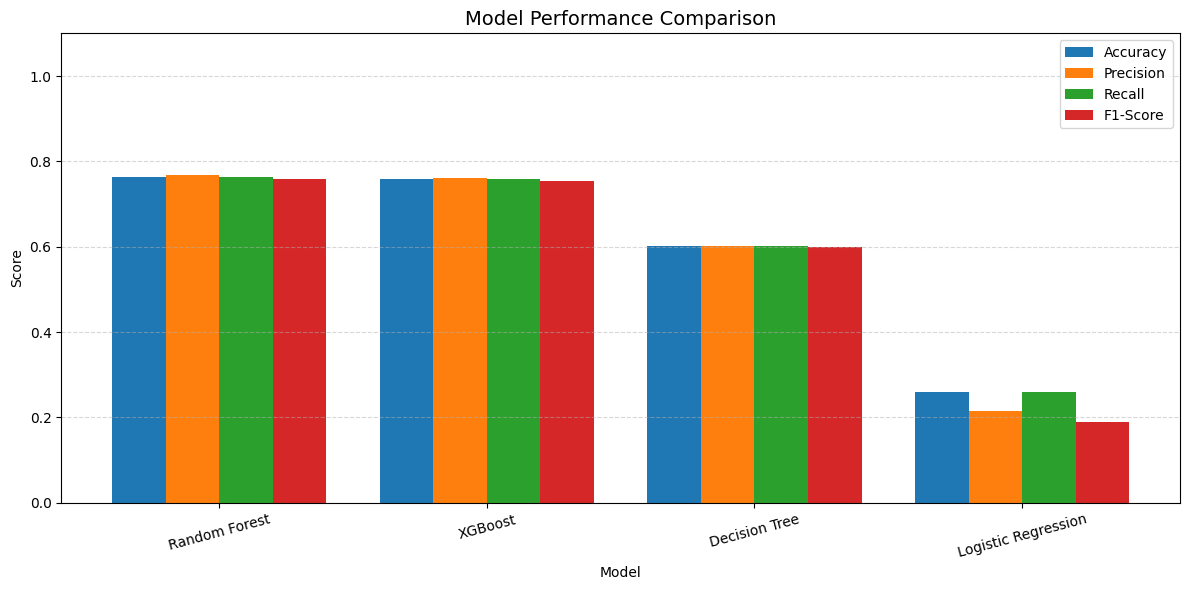

In [32]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='f1_weighted',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV F1-Score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-Score: 0.7396


In [36]:
from sklearn.metrics import classification_report

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print('=== Tuned Random Forest — Test Set Performance ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_best,
                             target_names=[str(c) for c in le.classes_]))

=== Tuned Random Forest — Test Set Performance ===
Accuracy  : 0.7707
F1-Score  : 0.7668

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       244
           1       0.80      0.94      0.86       238
           2       0.79      0.76      0.77       111
           3       0.72      0.57      0.63        92
           4       0.76      0.58      0.66        76
           5       0.86      0.69      0.77        97
           6       0.73      0.63      0.68        65
           7       0.65      0.74      0.69       140
           8       0.70      0.83      0.76       167
           9       0.77      0.72      0.74        99
          10       0.81      0.72      0.76        92
          11       0.92      0.56      0.70        62

    accuracy                           0.77      1483
   macro avg       0.78      0.72      0.74      1483
weighted avg       0.77      0.77      0.77      1483



---
## Step 5: Model Evaluation — Confusion Matrix

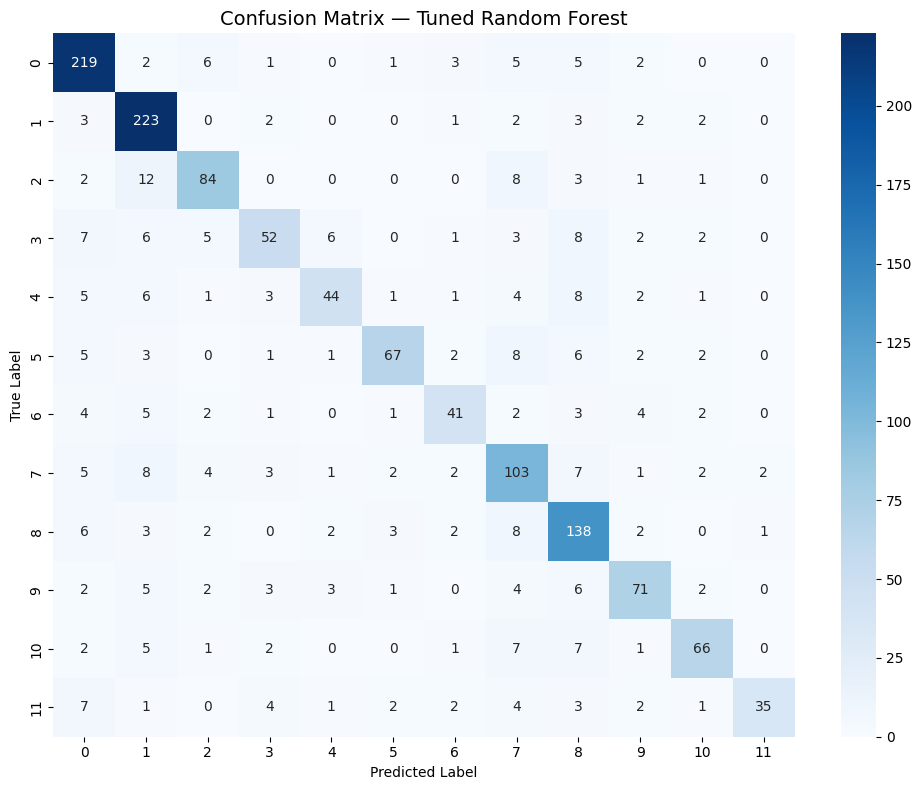

In [39]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Tuned Random Forest', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

5-Fold Cross-Validation F1 Scores:
  Fold 1: 0.5017
  Fold 2: 0.4059
  Fold 3: 0.5313
  Fold 4: 0.2768
  Fold 5: 0.3686

Mean  : 0.4169
Std   : 0.0920


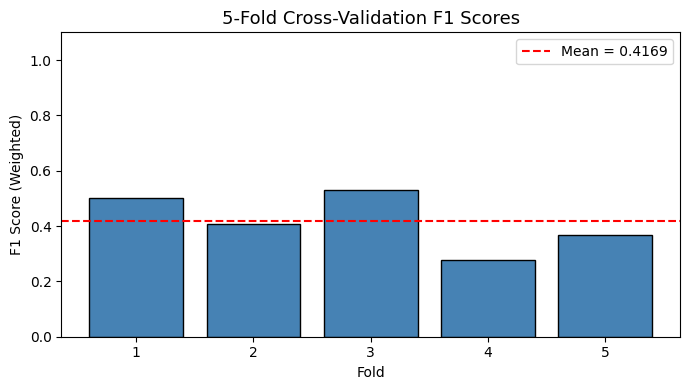

In [42]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

cv_scores = cross_val_score(best_model, X, y_encoded,
                             cv=5, scoring='f1_weighted', n_jobs=-1)

print('5-Fold Cross-Validation F1 Scores:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nMean  : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')

# Visualize
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross-Validation F1 Scores', fontsize=13)
plt.xlabel('Fold')
plt.ylabel('F1 Score (Weighted)')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_13046/673980551.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature',


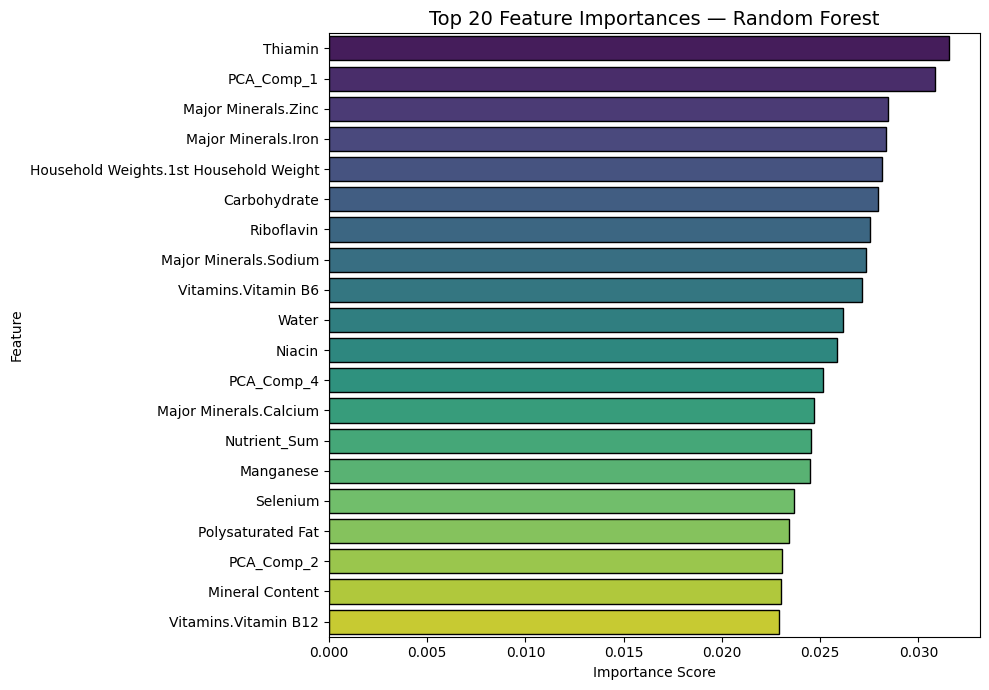

Top 10 Most Important Features:
                               Feature  Importance
                               Thiamin    0.031556
                            PCA_Comp_1    0.030856
                   Major Minerals.Zinc    0.028457
                   Major Minerals.Iron    0.028337
Household Weights.1st Household Weight    0.028162
                          Carbohydrate    0.027932
                            Riboflavin    0.027527
                 Major Minerals.Sodium    0.027356
                   Vitamins.Vitamin B6    0.027138
                                 Water    0.026157


In [43]:
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
            palette='viridis', edgecolor='black')
plt.title('Top 20 Feature Importances — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 Most Important Features:')
print(feat_imp_df.head(10).to_string(index=False))

In [47]:
import joblib

MODEL_PATH = 'tuned_random_forest_model.joblib'
joblib.dump(best_model, MODEL_PATH)
print(f'Model saved to: {MODEL_PATH}')

joblib.dump(le, 'label_encoder.pkl')
print('Label encoder saved to: label_encoder.pkl')

sample_pred = best_model.predict(X_test[:5])
print(f'\nSample predictions (reloaded model): {le.inverse_transform(sample_pred)}')
print(f'Actual labels                       : {le.inverse_transform(y_test[:5])}')

Model saved to: tuned_random_forest_model.joblib
Label encoder saved to: label_encoder.pkl

Sample predictions (reloaded model): [7 7 2 1 1]
Actual labels                       : [5 7 2 1 1]


In [45]:

final_acc = accuracy_score(y_test, y_pred_best)
final_f1  = f1_score(y_test, y_pred_best, average='weighted')
final_prec = precision_score(y_test, y_pred_best, average='weighted')
final_rec  = recall_score(y_test, y_pred_best, average='weighted')

print('=' * 55)
print('SUMMARY REPORT')
print('=' * 55)
print(f'Dataset         : Nutritional Food Data')
print(f'Task            : Multi-Class Classification')
print(f'Target Variable : FoodGroup (12 classes)')
print(f'Train Samples   : {X_train.shape[0]}')
print(f'Test Samples    : {X_test.shape[0]}')
print(f'Features Used   : {X.shape[1]}')
print('-' * 55)
print('Models Evaluated:')
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<22} Accuracy={row['Accuracy']:.4f}  F1={row['F1-Score']:.4f}")
print('-' * 55)
print('Best Model      : Random Forest (Tuned)')
print(f'Best Params     : {grid_search.best_params_}')
print(f'Test Accuracy   : {final_acc:.4f}')
print(f'Test F1-Score   : {final_f1:.4f}')
print(f'Test Precision  : {final_prec:.4f}')
print(f'Test Recall     : {final_rec:.4f}')
print(f'CV Mean F1      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('-' * 55)

SUMMARY REPORT
Dataset         : Nutritional Food Data
Task            : Multi-Class Classification
Target Variable : FoodGroup (12 classes)
Train Samples   : 5930
Test Samples    : 1483
Features Used   : 50
-------------------------------------------------------
Models Evaluated:
  Random Forest          Accuracy=0.7640  F1=0.7598
  XGBoost                Accuracy=0.7579  F1=0.7549
  Decision Tree          Accuracy=0.6022  F1=0.6001
  Logistic Regression    Accuracy=0.2589  F1=0.1886
-------------------------------------------------------
Best Model      : Random Forest (Tuned)
Best Params     : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Test Accuracy   : 0.7707
Test F1-Score   : 0.7668
Test Precision  : 0.7749
Test Recall     : 0.7707
CV Mean F1      : 0.4169 ± 0.0920
-------------------------------------------------------
